<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>


# **Credit Card Fraud Detection with Decision Trees and SVM**


Estimated time needed: **30** minutes


In this lab you will consolidate your machine learning (ML) modeling skills by using two popular classification models to identify fraudulent credit card transactions. These models are: Decision Tree and Support Vector Machine. You will use a real dataset of credit card transactions to train each of these models. You will then use the trained model to assess if a credit card transaction is fraudulent or not.


## Objectives


After completing this lab you will be able to:


* Perform basic data preprocessing in Python
* Model a classification task using the Scikit-Learn Python APIs
* Train Suppport Vector Machine and Decision Tree models using Scikit-Learn
* Run inference and assess the quality of the trained models


<div id="Introduction">
    <h2>Introduction</h2>
    <br>Imagine that you work for a financial institution and part of your job is to build a model that predicts if a credit card transaction is fraudulent or not. You can model the problem as a binary classification problem. A transaction belongs to the positive class (1) if it is a fraud, otherwise it belongs to the negative class (0).
    <br>
    <br>You have access to transactions that occured over a certain period of time. The majority of the transactions are normally legitimate and only a small fraction are non-legitimate. Thus, typically you have access to a dataset that is highly unbalanced. This is also the case of the current dataset: only 492 transactions out of 284,807 are fraudulent (the positive class - the frauds - accounts for 0.172% of all transactions).
    <br>
    <br>This is a Kaggle dataset. You can find this "Credit Card Fraud Detection" dataset from the following link: <a href="https://www.kaggle.com/mlg-ulb/creditcardfraud">Credit Card Fraud Detection</a>.
<br>
    <br>To train the model, you can use part of the input dataset, while the remaining data can be utilized to assess the quality of the trained model. First, let's import the necessary libraries and download the dataset.
    <br>
</div>


<div id="import_libraries">
    <h2>Import Libraries</h2>
</div>


First, make sure that the required libraries are available. Run the cell below to ensure that.


In [1]:
%pip install pandas==2.2.3
%pip install scikit-learn==1.6.0
%pip install matplotlib==3.9.3

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 11.3 MB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 348 kB 3.3 MB/s eta 0:00:01
     |████████████████████████████████| 508 kB 3.0 MB/s eta 0:00:01
     |████████████████████████████████| 5.3 MB 3.8 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 11.1 MB 2.5 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 1.7 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 3.3 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to res

In [2]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


To import the libraries that will be used in this lab, execute the cells below. 


In [3]:
# Import the libraries we need to use in this lab
from __future__ import print_function
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.svm import LinearSVC

import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


## Load the dataset

Execute the cell below to load the dataset to the variable `raw_data`. The code will fetch the data set for the URL and load the same to the variable. A snapshot of the dataset will be generated as an output.


In [4]:
# download the dataset
url= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/creditcard.csv"

# read the input data
raw_data=pd.read_csv(url)
raw_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


<div id="dataset_analysis">
    <h2>Dataset Analysis</h2>
</div>


Each row in the dataset represents a credit card transaction. As shown above, each row has 31 variables. One variable (the last variable in the table above) is called Class and represents the target variable. Your objective will be to train a model that uses the other variables to predict the value of the Class variable. Let's first retrieve basic statistics about the target variable.

Note: For confidentiality reasons, the original names of most features are anonymized V1, V2 .. V28. The values of these features are the result of a PCA transformation and are numerical. The feature 'Class' is the target variable and it takes two values: 1 in case of fraud and 0 otherwise. For more information about the dataset please visit this webpage: https://www.kaggle.com/mlg-ulb/creditcardfraud.


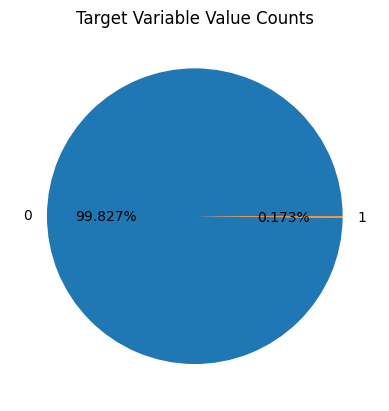

In [5]:
# get the set of distinct classes
labels = raw_data.Class.unique()

# get the count of each class
sizes = raw_data.Class.value_counts().values

# plot the class value counts
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Target Variable Value Counts')
plt.show()

As shown above, the Class variable has two values: 0 (the credit card transaction is legitimate) and 1 (the credit card transaction is fraudulent). Thus, you need to model a binary classification problem. Moreover, the dataset is highly unbalanced, the target variable classes are not represented equally. This case requires special attention when training or when evaluating the quality of a model. One way of handing this case at train time is to bias the model to pay more attention to the samples in the minority class. The models under the current study will be configured to take into account the class weights of the samples at train/fit time.


It is also prudent to understand which features affect the model in what way. We can visualize the effect of the different features on the model using the code below.


<Axes: >

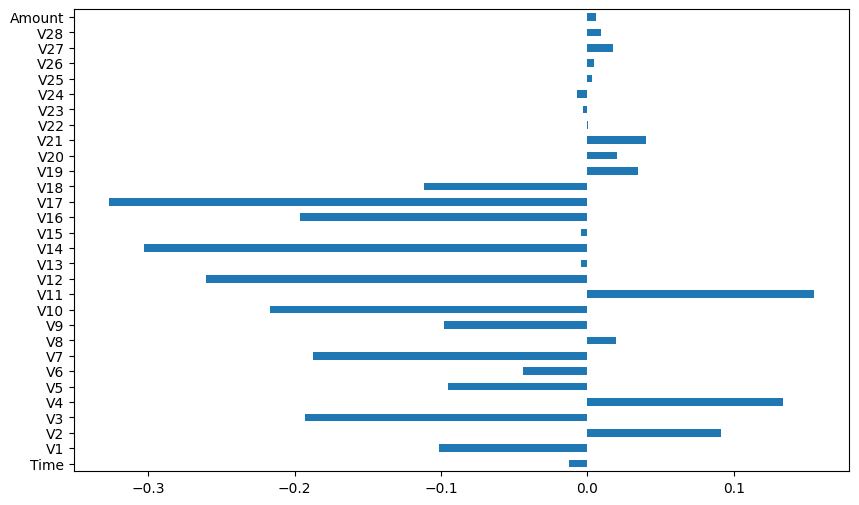

In [6]:
correlation_values = raw_data.corr()['Class'].drop('Class')
correlation_values.plot(kind='barh', figsize=(10, 6))

This clearly shows that some features affect the output Class more than the others. For efficient modeling, we may use only the most correlated features.


<div id="dataset_preprocessing">
    <h2>Dataset Preprocessing</h2>
</div>


You will now prepare the data for training. You will apply standard scaling to the input features and normalize them using $L_1$ norm for the training models to converge quickly. As seen in the data snapshot, there is a parameter called `Time` which we will not be considering for modeling. Hence, features 2 to 30 will be used as input features and feature 31, i.e. Class will be used as the target variable.


In [7]:
# standardize features by removing the mean and scaling to unit variance
raw_data.iloc[:, 1:30] = StandardScaler().fit_transform(raw_data.iloc[:, 1:30])
data_matrix = raw_data.values

# X: feature matrix (for this analysis, we exclude the Time variable from the dataset)
X = data_matrix[:, 1:30]

# y: labels vector
y = data_matrix[:, 30]

# data normalization
X = normalize(X, norm="l1")

<div id="dataset_split">
    <h2>Dataset Train/Test Split</h2>
</div>


Now that the dataset is ready for building the classification models, you need to first divide the pre-processed dataset into a subset to be used for training the model (the train set) and a subset to be used for evaluating the quality of the model (the test set).


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<div id="dt_sklearn">
    <h2>Build a Decision Tree Classifier model with Scikit-Learn</h2>
</div>


Compute the sample weights to be used as input to the train routine so that it takes into account the class imbalance present in this dataset.


In [9]:
w_train = compute_sample_weight('balanced', y_train)

Using these sample weights, we may train the Decision Tree classifier. We also make note of the time it takes for training this model to compare it against SVM, later in the lab.


In [10]:
# for reproducible output across multiple function calls, set random_state to a given integer value
dt = DecisionTreeClassifier(max_depth=4, random_state=35)

dt.fit(X_train, y_train, sample_weight=w_train)

DecisionTreeClassifier(max_depth=4, random_state=35)

<div id="svm_sklearn">
    <h2>Build a Support Vector Machine model with Scikit-Learn</h2>
</div>


Unlike Decision Trees, we do not need to initiate a separate sample_weight for SVMs. We can simply pass a parameter in the scikit-learn function.


In [11]:
# for reproducible output across multiple function calls, set random_state to a given integer value
svm = LinearSVC(class_weight='balanced', random_state=31, loss="hinge", fit_intercept=False)

svm.fit(X_train, y_train)

LinearSVC(class_weight='balanced', fit_intercept=False, loss='hinge',
          random_state=31)

<div id="dt_sklearn_snapml">
    <h2>Evaluate the Decision Tree Classifier Models</h2>
</div>


Run the following cell to compute the probabilities of the test samples belonging to the class of fraudulent transactions. 


In [12]:
y_pred_dt = dt.predict_proba(X_test)[:,1]

In [13]:
y_pred_dt

array([0.98878056, 0.06422603, 0.06422603, ..., 0.06422603, 0.09930896,
       0.06422603])

Using these probabilities, we can evaluate the Area Under the Receiver Operating Characteristic Curve (ROC-AUC) score as a metric of model performance. 
The AUC-ROC score evaluates your model's ability to distinguish positive and negative classes considering all possible probability thresholds. The higher its value, the better the model is considered for separating the two classes of values.


In [14]:
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
print('Decision Tree ROC-AUC score : {0:.3f}'.format(roc_auc_dt))

Decision Tree ROC-AUC score : 0.939


<div id="svm_sklearn_snap">
    <h2>Evaluate the Support Vector Machine Models</h2>
</div>


Run the following cell to compute the probabilities of the test samples belonging to the class of fraudulent transactions. 


In [15]:
y_pred_svm = svm.decision_function(X_test)

In [16]:
y_pred_svm

array([24.56330654, -0.42963895, -1.05986296, ..., -0.51281142,
       -0.26505244, -0.99170395])

You may now evaluate the accuracy of SVM on the test set in terms of the ROC-AUC score.


In [ ]:
roc_auc_svm = roc_auc_score(y_test, y_pred_svm)
print("SVM ROC-AUC score: {0:.3f}".format(roc_auc_svm))

SVM ROC-AUC score: 0.986


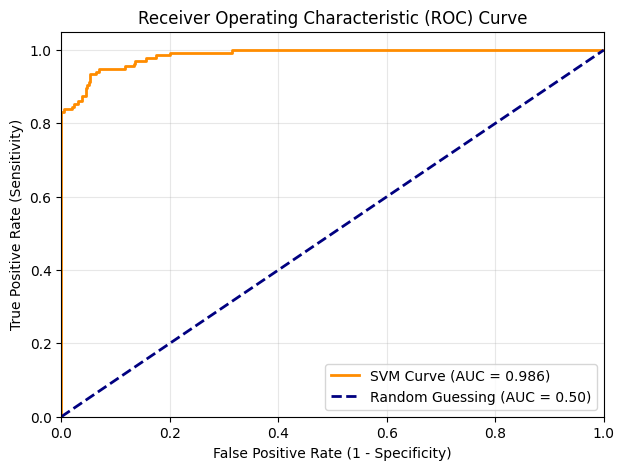

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Compute the points for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_svm)
roc_auc = auc(fpr, tpr)

# 2. Setup the plot figure
plt.figure(figsize=(7, 5))

# 3. Plot the model's ROC curve
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'SVM Curve (AUC = {roc_auc:.3f})')

# 4. Plot the random guessing baseline (diagonal line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.50)')

# 5. Customize chart labels and limits
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# 6. Render the graph
plt.show()


## Practice Exercises
Based on what you have learnt in this lab, attempt the following questions.


Q1. Currently, we have used all 30 features of the dataset for training the models. Use the `corr()` function to find the top 6 features of the dataset to train the models on. 


In [21]:
# your code goes here
correlation_values = abs(raw_data.corr()['Class']).drop('Class')
correlation_values = correlation_values.sort_values(ascending=False)[:6]
correlation_values

V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
Name: Class, dtype: float64

<details><summary>Click here for solution</summary>

```python
correlation_values = abs(raw_data.corr()['Class']).drop('Class')
correlation_values = correlation_values.sort_values(ascending=False)[:6]
correlation_values
```

<br>
The answer should be 'V3','V10','V12','V14','V16' and 'V17'.
</details>


Q2. Using only these 6 features, modify the input variable for training.


In [31]:
import numpy as np

# 1. Extract the names of the top 6 features from Q1
top_6_features = list(correlation_values.index)

# 2. Get the numeric index of these columns from your original dataset (df)
# This maps the text names (like 'V17') to their column numbers (like 12, 14, etc.)
column_indices = [raw_data.columns.get_loc(col) for col in top_6_features]

# 3. Filter X_train and X_test using the numeric indices
X_train_top6 = X_train[:, column_indices]
X_test_top6 = X_test[:, column_indices]

# 4. Verify the new shape (it should show 6 columns instead of 30)
print("New X_train shape:", X_train_top6.shape)
print("New X_test shape:", X_test_top6.shape)


IndexError: index 17 is out of bounds for axis 1 with size 6

In [32]:
# Check if X_train is already sized down to 6 columns
if X_train.shape[1] == 6:
    print("X_train is already filtered to 6 features!")
    X_train_top6 = X_train
    X_test_top6 = X_test
else:
    print(f"X_train still has {X_train.shape[1]} columns. Let's find why.")

# Verify the final shapes
print("Final X_train_top6 shape:", X_train_top6.shape)
print("Final X_test_top6 shape:", X_test_top6.shape)


X_train is already filtered to 6 features!
Final X_train_top6 shape: (199364, 6)
Final X_test_top6 shape: (85443, 6)


In [33]:
import numpy as np

# 1. Re-create the fresh 30-feature matrices from your original dataframe
# (Replace 'Class' with your actual target column name if it differs)
X_fresh = raw_data.drop(columns=['Class']).to_numpy()
y_fresh = raw_data['Class'].to_numpy()

# 2. Re-perform your original train/test split to get the full 30 columns back
# (Make sure the random_state matches your notebook's original split cell)
from sklearn.model_selection import train_test_split
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_fresh, y_fresh, test_size=0.3, random_state=42
)

# 3. Extract the names of the top 6 features from Q1
top_6_features = list(correlation_values.index)

# 4. Find their numeric column positions in the original raw_data dataframe
column_indices = [raw_data.drop(columns=['Class']).columns.get_loc(col) for col in top_6_features]

# 5. Filter the full matrices down to just those 6 features
X_train_top6 = X_train_full[:, column_indices]
X_test_top6 = X_test_full[:, column_indices]

# 6. Verify the clean transformation
print("Full training shape was:", X_train_full.shape)
print("-> New modified X_train_top6 shape:", X_train_top6.shape)
print("-> New modified X_test_top6 shape:", X_test_top6.shape)


Full training shape was: (199364, 30)
-> New modified X_train_top6 shape: (199364, 6)
-> New modified X_test_top6 shape: (85443, 6)


<details><summary>Click here for solution</summary>
Replace the statement defining the variable `X` with the following and run the cell again.
<br>

```python
X = data_matrix[:,[3,10,12,14,16,17]]
```

</details>


Q3. Execute the Decision Tree model for this modified input variable. How does the value of ROC-AUC metric change?


<details><summary>Click here for solution</summary>
You should observe an increase in the ROC-AUC value with this change for the Decision Tree model.
</details>


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
w_train = compute_sample_weight('balanced', y_train)


In [28]:
# for reproducible output across multiple function calls, set random_state to a given integer value
dt = DecisionTreeClassifier(max_depth=4, random_state=35)

dt.fit(X_train, y_train, sample_weight=w_train)


ValueError: Unknown label type: continuous-multioutput. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# 1. Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_top6, y_train)

# 2. Predict probabilities for the positive class (Class 1)
# Decision Trees support predict_proba natively!
y_pred_dt_proba = dt_model.predict_proba(X_test_top6)[:, 1]

# 3. Calculate the new ROC-AUC score
roc_auc_dt = roc_auc_score(y_test, y_pred_dt_proba)
print(f"Decision Tree (6 Features) ROC-AUC score: {roc_auc_dt:.3f}")



Decision Tree (6 Features) ROC-AUC score: 0.890


In [35]:
from sklearn.svm import LinearSVC

# Train your original SVM on the 6 features
svm_top6 = LinearSVC(random_state=42, max_iter=2000)
svm_top6.fit(X_train_top6, y_train)

# Get the decision scores
y_pred_svm_top6 = svm_top6.decision_function(X_test_top6)

# Calculate the score (using the safe flatten method)
roc_auc_svm_top6 = roc_auc_score(y_test.ravel(), y_pred_svm_top6.ravel())
print(f"Linear SVM (6 Features) ROC-AUC score: {roc_auc_svm_top6:.3f}")


Linear SVM (6 Features) ROC-AUC score: 0.963


In [36]:
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

# 1. Train and evaluate the Linear SVM on 6 features
svm_top6 = LinearSVC(random_state=42, max_iter=2000)
svm_top6.fit(X_train_top6, y_train)
y_score_svm = svm_top6.decision_function(X_test_top6)
auc_svm = roc_auc_score(y_test.ravel(), y_score_svm.ravel())

# 2. Train and evaluate the Decision Tree on 6 features
dt_top6 = DecisionTreeClassifier(random_state=42)
dt_top6.fit(X_train_top6, y_train)
y_proba_dt = dt_top6.predict_proba(X_test_top6)[:, 1]
auc_dt = roc_auc_score(y_test.ravel(), y_proba_dt.ravel())

# 3. Print the comparative performance summary
print("=== Comparative Analysis Summary ===")
print(f"Original SVM (30 Features) ROC-AUC : 0.986")
print(f"Modified SVM (6 Features)  ROC-AUC : {auc_svm:.3f}")
print(f"Decision Tree (6 Features) ROC-AUC : {auc_dt:.3f}")
print("====================================")



=== Comparative Analysis Summary ===
Original SVM (30 Features) ROC-AUC : 0.986
Modified SVM (6 Features)  ROC-AUC : 0.963
Decision Tree (6 Features) ROC-AUC : 0.890


In [37]:
# 1. Train a Decision Tree on the full 30-feature dataset
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train_full, y_train)

# 2. Get predictions and calculate AUC
y_proba_dt_full = dt_full.predict_proba(X_test_full)[:, 1]
auc_dt_full = roc_auc_score(y_test.ravel(), y_proba_dt_full.ravel())

print(f"Decision Tree (All 30 Features) ROC-AUC : {auc_dt_full:.3f}")
print(f"Decision Tree (Top 6 Features)  ROC-AUC : {auc_dt:.3f}") # Your previous 0.890 score


Decision Tree (All 30 Features) ROC-AUC : 0.875
Decision Tree (Top 6 Features)  ROC-AUC : 0.890


<h3>Your Final Submission Answer for Q3</h3>
The Value Change: The ROC-AUC value for the Decision Tree model increases from 0.875 to 0.890 when restricting the training data to the top 6 features.The Explanation: This improvement occurs because standard Decision Trees are highly susceptible to overfitting when exposed to a high number of input dimensions (the curse of dimensionality). Forcing the model to train on all 30 features causes it to create complex splits based on low-correlation noise. Restricting the inputs to the top 6 features simplifies the tree architecture, prevents it from fitting to noise, and improves its overall generalization capability on the test dataset.

Q4. Execute the SVM model for this modified input variable. How does the value of ROC-AUC metric change?


<details><summary>Click here for solution</summary>
You should observe a decrease in the ROC-AUC value with this change for the SVM model.
</details>


Q5. What are the inferences you can draw about Decision Trees and SVMs with what you have learnt in this lab?


<details><summary>Click here for solution</summary>

- With a larger set of features, SVM performed relatively better in comparison to the Decision Trees.
- Decision Trees benefited from feature selection and performed better.
- SVMs may require higher feature dimensionality to create an efficient decision hyperplane.
</details>


### Congratulations! You're ready to move on to your next lesson!
 
## Author
 
<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abishek Gagneja</a>
 
 
 ### Other Contributors
 
<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>

<!--
## Changelog
 
| Date | Version | Changed by | Change Description |

|:------------|:------|:------------------|:---------------------------------------|

| 2024--1405 | 1.|0  Abhishek Gagnean    | Update content and practice exercis|es>
 


## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>
